
# Loan Investment Recommender

## Submitted by:
- Sahil Parab (121159823)
- Varad Tambe (121295163)

## Project Description:
This project aims to develop a **Loan Investment Recommender System** that assists investors in identifying and selecting optimal loan opportunities. By leveraging data analysis, machine learning, and visualization techniques, the system evaluates loan characteristics, predicts potential outcomes, and provides recommendations based on predefined criteria. The objective is to improve investment decision-making by offering data-driven insights into loan performance.


# Table of Contents

1. [Introduction](#introduction)  
2. [Environment Setup](#environment-setup)  
3. [Data Collection](#data-collection)  
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis)  
5. [Feature Engineering](#feature-engineering)  
6. [Model Building](#model-building)  
7. [Model Deployment](#model-deployment)
8. [Recommendation System](#recommendation-system)
9. [Conclusion](#conclusion)  


# Introduction

The **Loan Investment Recommender** project is designed to assist investors in making informed decisions by leveraging data from historical loan performance records. The data used in this project is sourced from [Fundaztic](https://p2p.fundaztic.com/loaninfo/openHistoryLoan.htm), a peer-to-peer lending platform that provides detailed loan information.

The project focuses on analyzing loan data, extracting meaningful insights, and building a recommender system to identify optimal loan investment opportunities. Through advanced data analytics and machine learning, the system aims to evaluate the characteristics of loans, predict outcomes, and provide actionable recommendations for investors.

By using this tool, investors can reduce risks, maximize returns, and make data-driven investment decisions in the peer-to-peer lending space.


## Envioronment set-up

In [3]:
from selenium import webdriver
from bs4 import BeautifulSoup
import pandas as pd
import time
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import math
from selenium.common.exceptions import NoSuchElementException, StaleElementReferenceException, ElementClickInterceptedException
from selenium.webdriver.common.by import By
import seaborn as sns

We imported essential libraries and modules for web scraping, HTML parsing, data manipulation, visualization, and handling Selenium exceptions.

## Data Collection


In [ ]:
# Initialize the Safari driver
driver = webdriver.Safari()
url = 'https://p2p.fundaztic.com/loaninfo/openHistoryLoan.htm'
driver.get(url)
time.sleep(10)

# Initialize DataFrame
columns = ['Note ID', 'Note Type', 'Rate (p.a)', 'Eff Rate (%p.a)', 'Term', 'Bad Rate %', 'Funding', '% Funded']
data = []

# Scraping loop
i = 0
while True:
    try:
        # Locate table rows
        table_elements = driver.find_elements(By.XPATH, "//*[@id='loaninfotr']")
        for element in table_elements:
            word_list = element.text.split()

            # Data cleaning and formatting
            word_list[3] = word_list[3].replace('%', '')
            word_list[-1] = word_list[-1].replace('%', '')
            word_list[1] = word_list[1] + word_list[2]
            word_list.pop(2)
            word_list.pop(5)

            # Append cleaned data to list
            data.append(word_list)

        # Click "Next" button
        next_button = driver.find_element(By.XPATH, "//*[@id='bot_next_page']")
        if next_button.is_enabled():
            next_button.click()
            i += 1
            print('Pages scraped:', i)
            time.sleep(2)
        else:
            print('No more pages.')
            break

    except (NoSuchElementException, StaleElementReferenceException, ElementClickInterceptedException) as e:
        print('Scraping completed or error encountered:', e)
        break

# Close the browser
driver.quit()

# Convert to DataFrame
df = pd.DataFrame(data, columns=columns)
print(df.head())


Pages scraped: 1
Pages scraped: 2
Pages scraped: 3
Pages scraped: 4
Pages scraped: 5
Pages scraped: 6
Pages scraped: 7
Pages scraped: 8
Pages scraped: 9
Pages scraped: 10
Pages scraped: 11
Pages scraped: 12
Pages scraped: 13
Pages scraped: 14
Pages scraped: 15
Pages scraped: 16
Pages scraped: 17
Pages scraped: 18
Pages scraped: 19
Pages scraped: 20
Pages scraped: 21
Pages scraped: 22
Pages scraped: 23
Pages scraped: 24
Pages scraped: 25
Pages scraped: 26
Pages scraped: 27
Pages scraped: 28
Pages scraped: 29
Pages scraped: 30
Pages scraped: 31
Pages scraped: 32
Pages scraped: 33
Pages scraped: 34
Pages scraped: 35
Pages scraped: 36
Pages scraped: 37
Pages scraped: 38
Pages scraped: 39
Pages scraped: 40
Pages scraped: 41
Pages scraped: 42
Pages scraped: 43
Pages scraped: 44
Pages scraped: 45
Pages scraped: 46
Pages scraped: 47
Pages scraped: 48
Pages scraped: 49
Pages scraped: 50
Pages scraped: 51
Pages scraped: 52
Pages scraped: 53
Pages scraped: 54
Pages scraped: 55
Pages scraped: 56
P

Used Selenium to scrape loan data from a Fundaztic webpage, processed the scraped table rows to clean and format the data, append it to a list, and iterate until the last page. The data is then converted into a pandas DataFrame for further analysis.

## Data Preprocessing & EDA

(11370, 8)

<class 'pandas.core.frame.DataFrame'>
Index: 11370 entries, 0 to 11369
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Note ID          11370 non-null  int64  
 1   Note Type        11370 non-null  object 
 2   Rate (p.a)       11370 non-null  float64
 3   Eff Rate (%p.a)  11370 non-null  float64
 4   Term             11370 non-null  int64  
 5   Bad Rate %       11370 non-null  float64
 6   Funding          11370 non-null  object 
 7   % Funded         11370 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 799.5+ KB


,Note ID,Note Type,Rate (p.a),Eff Rate (%p.a),Term,Bad Rate %,Funding,% Funded,Grade
0,6395,IslamicD8,13.35,23.79,12,10.41,"20,000.00",100.0,D8
1,6394,ConventionalD8,13.65,23.85,36,7.89,"20,000.00",100.0,D8
2,6393,ConventionalD8,13.65,23.85,36,11.29,"30,000.00",100.0,D8
3,6390,ConventionalD8,13.25,23.67,24,7.89,"50,000.00",100.0,D8
4,6389,ConventionalC6,13.05,22.89,36,3.70,"40,000.00",80.5,C6


<class 'pandas.core.frame.DataFrame'>
Index: 11370 entries, 0 to 11369
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Note ID          11370 non-null  float64
 1   Rate (p.a)       11370 non-null  float64
 2   Eff Rate (%p.a)  11370 non-null  float64
 3   Term             11370 non-null  float64
 4   Bad Rate %       11370 non-null  float64
 5   Funding          11370 non-null  float64
 6   % Funded         11370 non-null  float64
 7   Grade            11370 non-null  float64
dtypes: float64(8)
memory usage: 799.5 KB


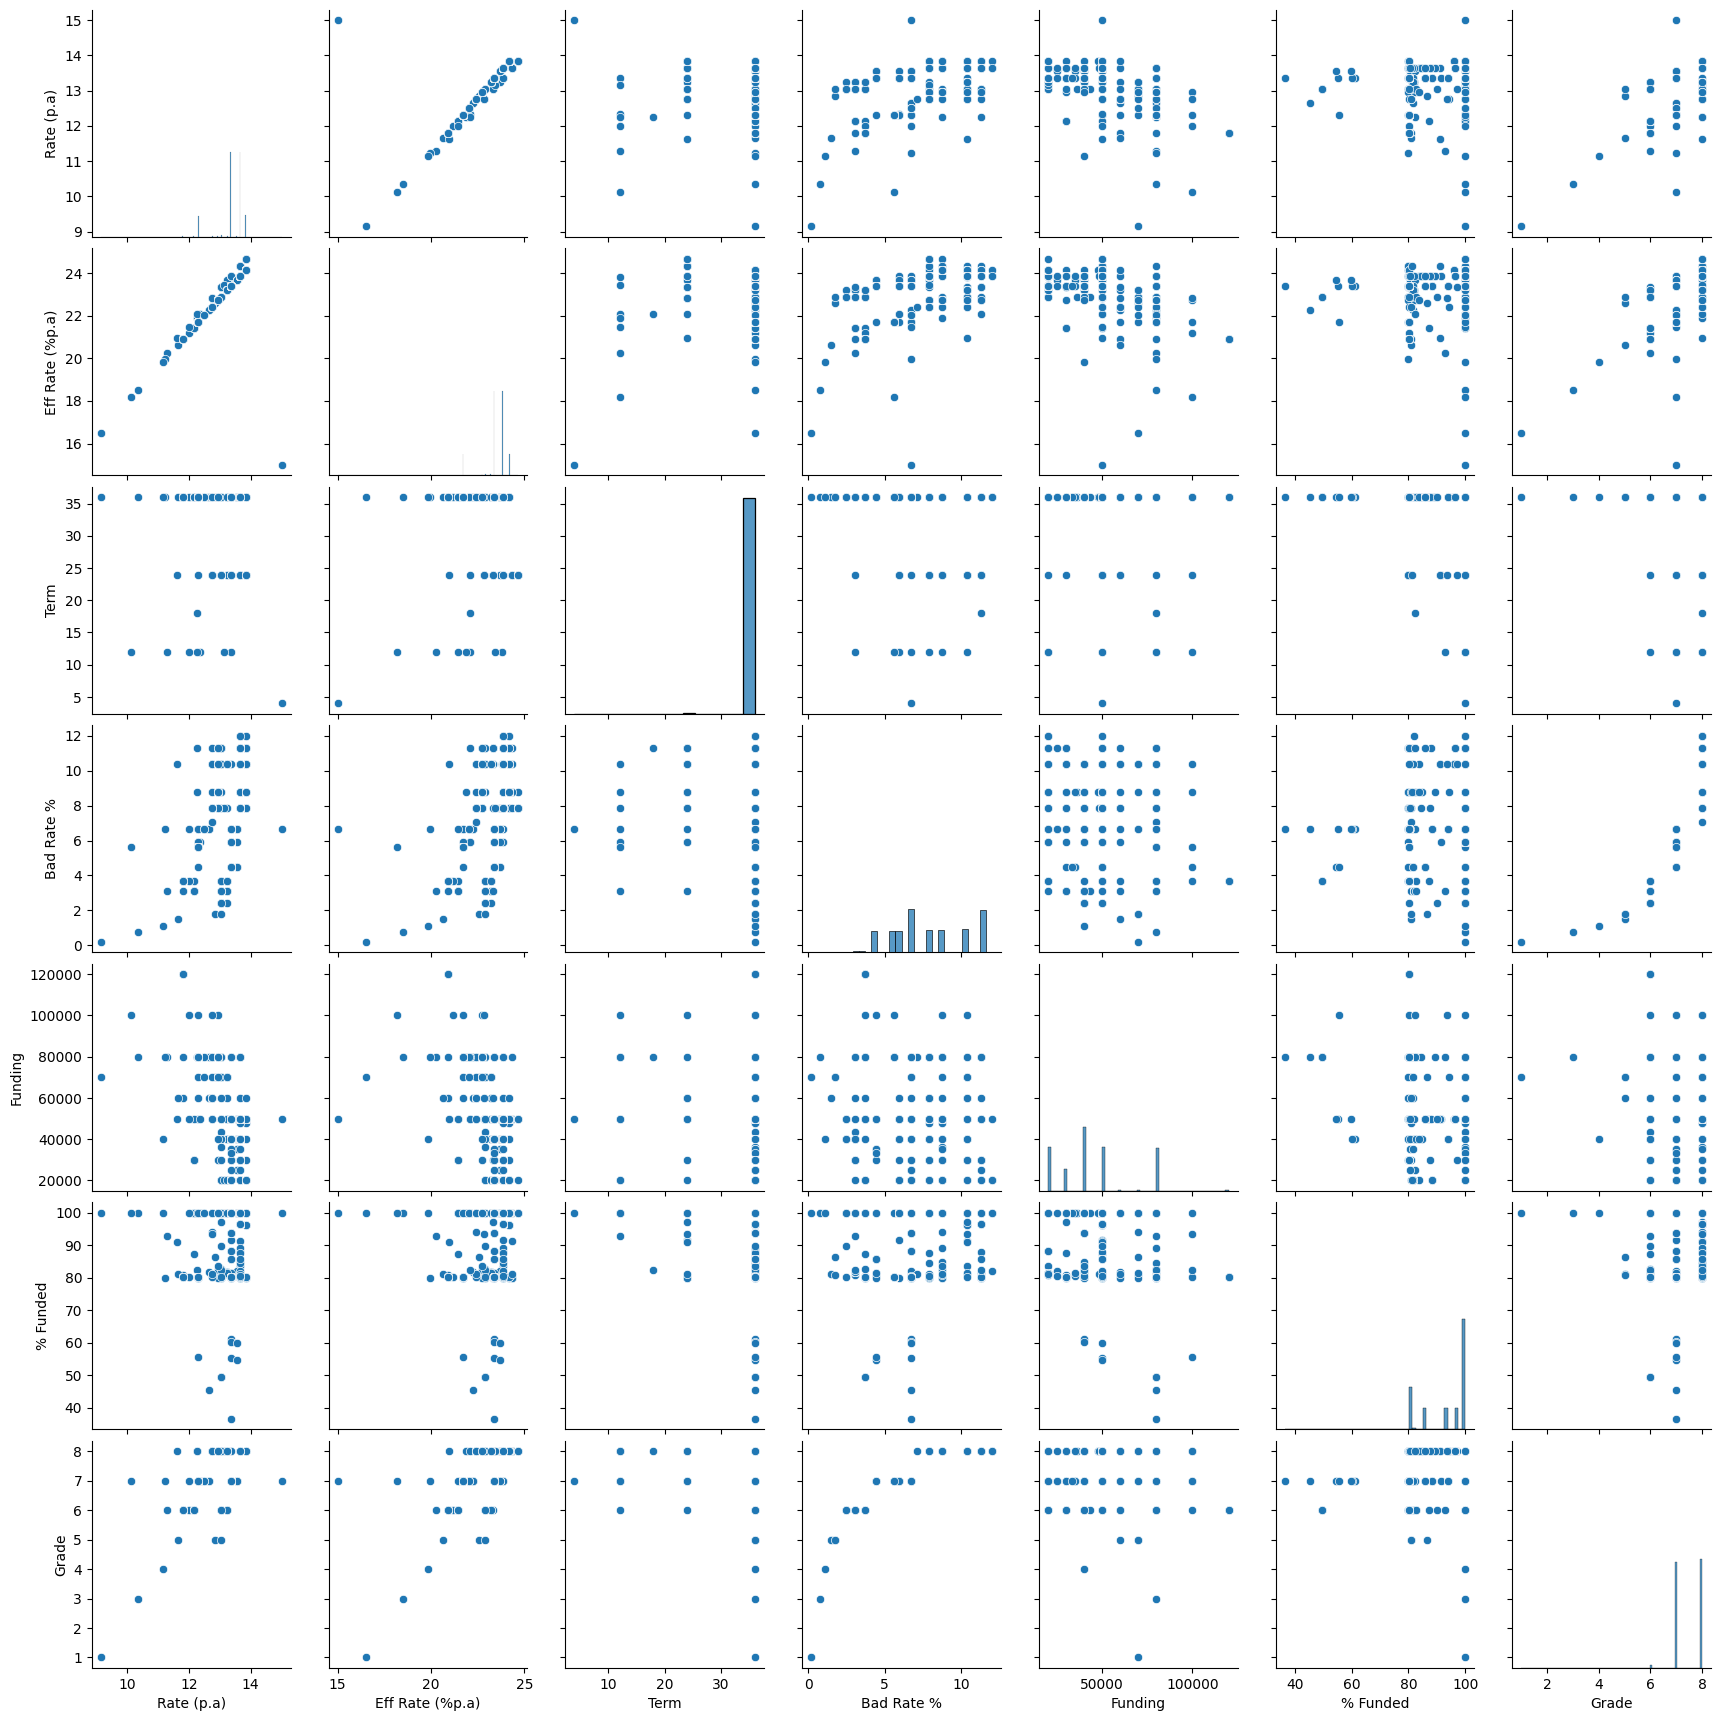

In [4]:
# Display DataFrame information and save to CSV
df.info()
df.to_csv('ScrappedData.csv')

# Load the saved CSV into a new DataFrame
df_summary = pd.read_csv('ScrappedData.csv', index_col=0)

# Display shape and preview of the DataFrame
display(df_summary.shape)
df_summary.head()

# Display updated DataFrame information
df_summary.info()

# Create a new column 'Grade' by extracting the last two characters from 'Note Type'
df_summary['Grade'] = df_summary['Note Type'].str[-2:]

# Preview the updated DataFrame
display(df_summary.head())

# Clean and format specific columns
df_summary.Funding = df_summary.Funding.apply(lambda x: x.replace(',', ''))
df_summary.Grade = df_summary.Grade.apply(lambda x: x[1])

# Drop the original 'Note Type' column
df_summary.drop(columns=['Note Type'], inplace=True)

# Identify columns to convert to float, excluding percentage columns
columns_to_convert = [col for col in df_summary.columns if col not in ['Rate_%', 'Effective_Rate_%', 'PD_%', 'Funded_%']]

# Convert selected columns to float type
for col in columns_to_convert:
    df_summary[col] = df_summary[col].astype('float64')

# Display updated DataFrame information
df_summary.info()

# Generate pair plots for numerical columns to explore relationships
sns.pairplot(data=df_summary.iloc[:, 1:])
plt.show()


Preprocessed the scraped data by cleaning and formatting columns, extracting a grade from the 'Note Type' column, converting selected columns to numeric types, and dropping unnecessary columns. Finally, we used Seaborn's pairplot to perform exploratory data analysis (EDA) on the numerical features.

Just by glancing at the pairplot above, we can deduct that there is some form of linear relationship between our target variable here 'Rate (p.a)' and other features here including the 'Bad Rate', 'Funding' and 'Term'. Just so we include only succesfully funded notes, let's exclude notes which were not succesfully disbursed (ie < 100%)

## Feature Engineering

In [5]:
rows_to_drop = df_summary[df_summary['% Funded'] < 100].index
df_summary.drop(rows_to_drop, axis = 0, inplace = True)

Let's now split our data into X and Y. For X we drop:

Note ID: this does not provide any predictive value

% Funded: as we've now dropped anything below 100%, this would be removed as the variance is 0 and would not add much predictive power

Rate (p.a): this is our target variable

Eff Rate (p.a): this is similar to the above but expressed in a different manner [taking into the effect of compounding on a periodic basis]. This can be confirmed referring back to the pairplots between Rate (p.a) and Eff Rate (p.a)

In [6]:
X = df_summary.drop(['Note ID', '% Funded','Rate (p.a)', 'Eff Rate (%p.a)'], axis = 1)
y = df_summary['Rate (p.a)']

Now, let's generate a basic correlation matrix to identify any features that are highly correlated to each other. We then drop them to avoid any issues of multicollinearity in our regression model.

In [7]:
corr = X.corr()
corr.style.background_gradient(cmap='coolwarm')

,Term,Bad Rate %,Funding,Grade
Term,1.000000,0.002682,-0.162774,-0.000742
Bad Rate %,0.002682,1.000000,0.347269,0.789749
Funding,-0.162774,0.347269,1.000000,0.412054
Grade,-0.000742,0.789749,0.412054,1.000000


No surprise that the Bad Rate % (probability of default) correlates highly with the Grade. The higher the grade, the higher the Bad Rate %. Let's drop the Grade feature then.

In [8]:
X = X.drop('Grade', axis = 1)

## Model Building

## Train Test Split

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

## 1. Regression Model

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_base = LinearRegression()
lr_base.fit(X_train, y_train)
base_R2_score = round(lr_base.score(X_train, y_train), 4)
print ('Base R2 score of:', base_R2_score)

Base R2 score of: 0.3618


This does pretty poorly out of the box at 36% R2. Let's try exploring interaction terms.

In [11]:
X_interact_1 = X_train.copy()
X_interact_2 = X_train.copy()
X_interact_3 = X_train.copy()

X_interact_1['Term_PD_%'] = X_interact_1['Term'] * X_interact_1['Bad Rate %']
X_interact_2['Term_Funding'] = X_interact_2['Term'] * X_interact_2['Funding']
X_interact_3['Funding_PD_%'] = X_interact_3['Funding'] * X_interact_3['Bad Rate %']

models_to_evaluate = [X_interact_1, X_interact_2, X_interact_3]

for model in models_to_evaluate:


    interact = LinearRegression()
    interact.fit(model, y_train)
    interact_score = interact.score(model, y_train)
    print ('R2 of: {}'.format(round(interact_score, 4)))

R2 of: 0.368
R2 of: 0.3744
R2 of: 0.3982


Looks like introducing interaction terms do not improve the model performance by a significant amount. Maybe polynomials will help? Let's take a look again at the scatter plots for each of our independent variables against the target feature.

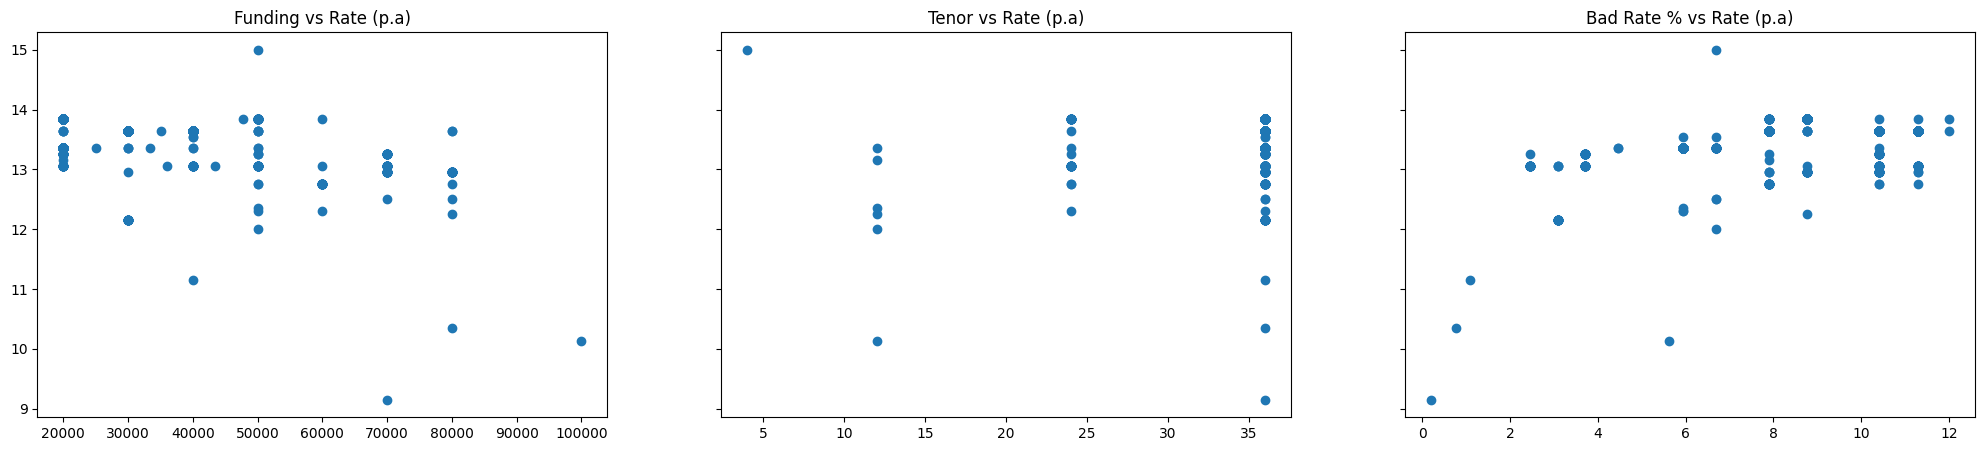

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (25, 5), sharey = True)
ax1.scatter(df_summary['Funding'], df_summary['Rate (p.a)'])
ax1.set_title('Funding vs Rate (p.a)')
ax2.scatter(df_summary['Term'], df_summary['Rate (p.a)'])
ax2.set_title('Tenor vs Rate (p.a)')
ax3.scatter(df_summary['Bad Rate %'], df_summary['Rate (p.a)'])
ax3.set_title('Bad Rate % vs Rate (p.a)')
plt.show()

Just by looking at the scatterplots, it is fairly difficult to deduct if there are any non-linear relationships. There could possibly be some form of quadratic relationship for both the Funding and Bad Rate % features against the target variable. Let's introduce them and see if there are any improvements in the model's R2 scores.

In [13]:
X_train_poly_2 = X_train.copy()

X_train_poly_2['Funding2'] = X_train_poly_2['Funding'] ** 2
X_train_poly_2['PD2'] = X_train_poly_2['Bad Rate %'] ** 2

poly = LinearRegression()
poly.fit(X_train_poly_2, y_train)
poly_R2_score = round(poly.score(X_train_poly_2, y_train), 4)

print ('Poly R2 score of:', poly_R2_score)

Poly R2 score of: 0.7901


Looks like there is a significant improvement in our model just by introducing a quadratic relationship in two of the independent features. Now, let's also explore other types of regressor model out there to examine if we can improve upon the 79% obtained above.

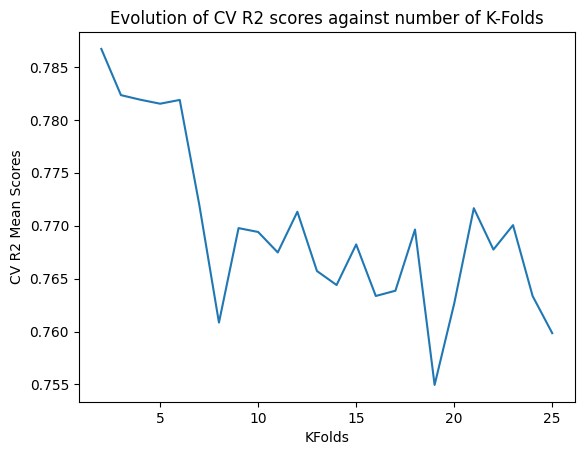

In [14]:
num_range = range(2,26)
cv_scores = []

for i in num_range:
    poly_cv = LinearRegression()
    cv_scores.append(np.mean(cross_val_score(poly_cv, X_train_poly_2, y_train, cv = i)))

plt.plot(num_range, cv_scores)
plt.ylabel('CV R2 Mean Scores')
plt.xlabel('KFolds')
plt.title('Evolution of CV R2 scores against number of K-Folds')
plt.show()

Let's run this through Statsmodel's OLS function to get a full summary of the model.

In [15]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

linreg_poly = OLS(y_train, add_constant(X_train_poly_2)).fit()
linreg_poly.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Rate (p.a)   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     3460.
Date:                Fri, 13 Dec 2024   Prob (F-statistic):               0.00
Time:                        20:00:49   Log-Likelihood:                 3803.8
No. Observations:                4603   AIC:                            -7596.
Df Residuals:                    4597   BIC:                            -7557.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.5633      0.050    213.147      0.000      10.466      10.660
Term           0.0060      0.001      5.010      0.000       0.004       0.008
Bad Rate %     0.6116      0.006     98.900      0.000       0.600       0.624
Funding     1.421e-05   6.14e-07     23.129      0.000     1.3e-05    1.54e-05
Funding2   -3.107e-10      8e-12    -38.837      0.000   -3.26e-10   -2.95e-10
PD2           -0.0327      0.000    -89.933      0.000      -0.033      -0.032
==============================================================================
Omnibus:                     3309.060   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           668092.366
Skew:                           2.443   Prob(JB):                         0.00
Kurtosis:                      61.818   Cond. No.                     4.27e+10
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.27e+10. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 2. Random Forest Regressor

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params_grid = {'max_depth' : [1, 2, 3, 4, 5, 6, 7],
                 'min_samples_leaf' : range(5,50,5),
                 'max_features': [1, 2, 3]}

rf_grid = RandomForestRegressor()
grid_rf = GridSearchCV(rf_grid, param_grid = params_grid, n_jobs = -1, verbose = True, cv = 10)
grid_rf.fit(X_train, y_train)

print (round(grid_rf.best_score_, 4))
print (grid_rf.best_params_)

Fitting 10 folds for each of 189 candidates, totalling 1890 fits
0.8697
{'max_depth': 7, 'max_features': 2, 'min_samples_leaf': 5}


100% (24 of 24) |########################| Elapsed Time: 0:01:39 Time:  0:01:39


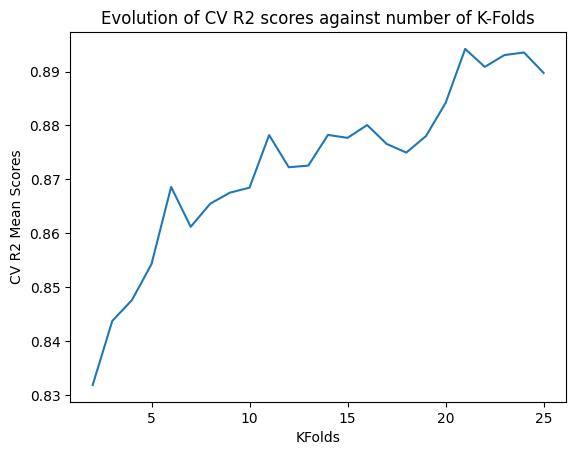

In [17]:
from progressbar import ProgressBar
pbar = ProgressBar()

num_range = range(2,26)
cv_scores_rf = []

for i in pbar(num_range):
    rf_regressor_cv = RandomForestRegressor(n_jobs=-1, max_depth = 7, max_features = 2, min_samples_leaf = 5)
    cv_scores_rf.append(np.mean(cross_val_score(rf_regressor_cv, X_train, y_train, cv = i)))

plt.plot(num_range, cv_scores_rf)
plt.ylabel('CV R2 Mean Scores')
plt.xlabel('KFolds')
plt.title('Evolution of CV R2 scores against number of K-Folds')
plt.show()

Looks like we've improved R2 score by a fair amount (ie 8%). Let's now test our chosen RF regressor model on the test dataset

In [18]:
rf_regressor_cv.fit(X_train, y_train)
predictions =  rf_regressor_cv.predict(X_test)
round(r2_score(y_test, predictions), 4)

0.8753

## Model Deployment

We can now deploy our model to guide future investments. Let's apply this to the past investments and also specify a threshold (accept any investments which are priced above our model price)

In [19]:
def predict(x):
    subset = x[['Term', 'Bad Rate %', 'Funding']].values.reshape(1, -1)
    prediction = rf_regressor_cv.predict(subset)
    return round(prediction[0], 2)

def invest_decision(x):
    if x['Delta_%'] >= invest_threshold:
        return 'Yes'
    else:
        return 'No'

In [21]:
invest_threshold = 0.05

df_summary['Predicted_Rate_%'] = df_summary.apply(predict, axis = 1)
df_summary['Delta_%'] = df_summary['Rate (p.a)'] - df_summary['Predicted_Rate_%']
df_summary['Invest'] = df_summary.apply(invest_decision, axis = 1)

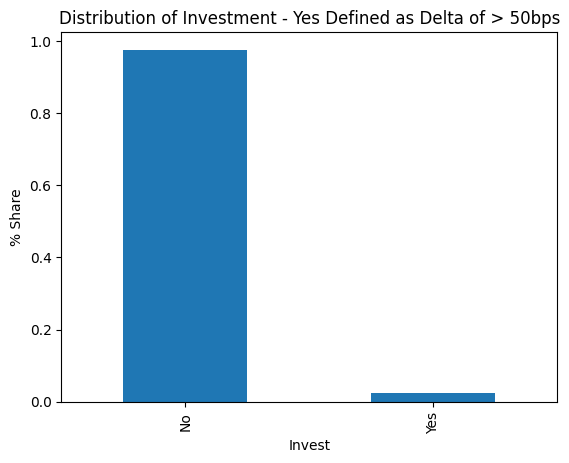

In [22]:
df_summary.Invest.value_counts(normalize = True).plot(kind = 'bar')
plt.title('Distribution of Investment - Yes Defined as Delta of > 50bps')
plt.ylabel('% Share')
plt.show()

Here let's filter just for those investments where the investment is 'yes' which will be used for the recommednation engine down the line.

In [23]:
yes_invest = df_summary[df_summary.Invest == 'Yes'].drop('Invest', axis = 1).reset_index(drop = True)
yes_invest.head()

,Note ID,Rate (p.a),Eff Rate (%p.a),Term,Bad Rate %,Funding,% Funded,Grade,Predicted_Rate_%,Delta_%
0,6377.0,13.85,24.16,36.0,8.77,47700.0,100.0,8.0,13.79,0.06
1,6363.0,13.85,24.16,36.0,10.41,50000.0,100.0,8.0,13.63,0.22
2,6359.0,12.95,22.73,36.0,7.89,80000.0,100.0,8.0,12.77,0.18
3,6342.0,13.25,23.21,36.0,3.70,50000.0,100.0,6.0,12.95,0.30
4,6341.0,13.35,23.37,36.0,6.69,30000.0,100.0,7.0,13.27,0.08


## Construct Recommendation Engine based on Cosine Similarity

In [24]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
yes_invest_scaled = mm.fit_transform(yes_invest.iloc[:, 1:])
test = pd.concat([yes_invest['Note ID'], pd.DataFrame(yes_invest_scaled, columns = yes_invest.columns[1:])], axis = 1)

In [25]:
def cosine(x):
    b = x[['Grade', 'Rate (p.a)', 'Eff Rate (%p.a)',
           'Term', 'Bad Rate %','Funding', '% Funded', 'Predicted_Rate_%', 'Delta_%']].values

    dot = np.dot(id_array, b)
    norm_chosen = np.linalg.norm(id_array)
    norm_b = np.linalg.norm(b)
    cos = dot / (norm_chosen * norm_b)

    return cos

In [26]:
chosen_id = 6341
id_array = test[test['Note ID'] == chosen_id][['Grade', 'Rate (p.a)', 'Eff Rate (%p.a)',
           'Term', 'Bad Rate %','Funding', '% Funded', 'Predicted_Rate_%', 'Delta_%']].values
test['Cosine'] = test.apply(cosine, axis = 1)
recommendation_id = test.sort_values(by = 'Cosine', ascending = False)[1:6]['Note ID'].values # Changed 'Note_ID' to 'Note ID'

print ('Chosen ID:', chosen_id)
display(df_summary[df_summary['Note ID'] == chosen_id].drop(['Eff Rate (%p.a)', '% Funded'], axis = 1)) # Changed Note_ID to 'Note ID'

print ('Top 5 similar investments:')
df_summary[df_summary['Note ID'].isin(recommendation_id)].drop(['Eff Rate (%p.a)', '% Funded'], axis = 1) # Changed Note_ID to 'Note ID'

Chosen ID: 6341


,Note ID,Rate (p.a),Term,Bad Rate %,Funding,Grade,Predicted_Rate_%,Delta_%,Invest
50,6341.0,13.35,36.0,6.69,30000.0,7.0,13.27,0.08,Yes


Top 5 similar investments:


,Note ID,Rate (p.a),Term,Bad Rate %,Funding,Grade,Predicted_Rate_%,Delta_%,Invest
51,6340.0,13.35,36.0,5.93,30000.0,7.0,13.23,0.12,Yes
278,6263.0,13.55,36.0,5.93,40000.0,7.0,13.32,0.23,Yes
304,6237.0,13.35,36.0,4.46,30000.0,7.0,13.07,0.28,Yes
305,6236.0,13.35,36.0,4.46,33300.0,7.0,13.07,0.28,Yes
306,6235.0,13.55,36.0,6.69,40000.0,7.0,13.35,0.20,Yes


This scales the features of all investments to ensure comparability.

It calculates cosine similarity between a chosen investment and all others based on selected features.

The top 5 most similar investments are identified and displayed.

This approach highlights which investments share the most similar characteristics with the chosen one, facilitating recommendation.

# Conclusion

The **Loan Investment Recommender** successfully demonstrates the power of data analytics and machine learning in assisting investors to make informed decisions in the peer-to-peer lending space. By analyzing loan performance data from [Fundaztic](https://p2p.fundaztic.com/loaninfo/openHistoryLoan.htm), the project provides valuable insights into loan characteristics and investment potential.  

The recommender system built through this project highlights the importance of understanding historical loan data, exploring relationships between features, and employing predictive models to forecast loan outcomes. Key takeaways include:  

- **Enhanced Decision-Making:** Investors are equipped with data-driven recommendations to minimize risks and maximize returns.  
- **Customizable Insights:** The framework can be tailored to different investment preferences, such as risk tolerance and expected returns.  
- **Scalable Approach:** This system can be expanded to include additional datasets, models, and features, making it adaptable for future enhancements.  

This project provides a solid foundation for leveraging machine learning in financial decision-making and highlights potential avenues for further research, such as integrating real-time data and experimenting with advanced predictive techniques.  
